In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("../data/time_series_covid19_confirmed_global.csv")

In [5]:
df.head()

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,2/28/23,3/1/23,3/2/23,3/3/23,3/4/23,3/5/23,3/6/23,3/7/23,3/8/23,3/9/23
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,209322,209340,209358,209362,209369,209390,209406,209436,209451,209451
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,334391,334408,334408,334427,334427,334427,334427,334427,334443,334457
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,271441,271448,271463,271469,271469,271477,271477,271490,271494,271496
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,47866,47875,47875,47875,47875,47875,47875,47875,47890,47890
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,105255,105277,105277,105277,105277,105277,105277,105277,105288,105288


In [6]:
df.shape

(289, 1147)

In [7]:
df.columns

Index(['Province/State', 'Country/Region', 'Lat', 'Long', '1/22/20', '1/23/20',
       '1/24/20', '1/25/20', '1/26/20', '1/27/20',
       ...
       '2/28/23', '3/1/23', '3/2/23', '3/3/23', '3/4/23', '3/5/23', '3/6/23',
       '3/7/23', '3/8/23', '3/9/23'],
      dtype='str', length=1147)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 289 entries, 0 to 288
Columns: 1147 entries, Province/State to 3/9/23
dtypes: float64(2), int64(1143), str(2)
memory usage: 2.5 MB


In [9]:
df.isnull().sum()

Province/State    198
Country/Region      0
Lat                 2
Long                2
1/22/20             0
                 ... 
3/5/23              0
3/6/23              0
3/7/23              0
3/8/23              0
3/9/23              0
Length: 1147, dtype: int64

In [10]:
df.tail()

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,2/28/23,3/1/23,3/2/23,3/3/23,3/4/23,3/5/23,3/6/23,3/7/23,3/8/23,3/9/23
284,NaN,West Bank and Gaza,31.952200,35.233200,0,0,0,0,0,0,...,703228,703228,703228,703228,703228,703228,703228,703228,703228,703228
285,NaN,Winter Olympics 2022,39.904200,116.407400,0,0,0,0,0,0,...,535,535,535,535,535,535,535,535,535,535
286,NaN,Yemen,15.552727,48.516388,0,0,0,0,0,0,...,11945,11945,11945,11945,11945,11945,11945,11945,11945,11945
287,NaN,Zambia,-13.133897,27.849332,0,0,0,0,0,0,...,343012,343012,343079,343079,343079,343135,343135,343135,343135,343135
288,NaN,Zimbabwe,-19.015438,29.154857,0,0,0,0,0,0,...,263921,264127,264127,264127,264127,264127,264127,264127,264276,264276


In [12]:
df.describe()

,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,1/28/20,1/29/20,...,2/28/23,3/1/23,3/2/23,3/3/23,3/4/23,3/5/23,3/6/23,3/7/23,3/8/23,3/9/23
count,287.000000,287.000000,289.000000,289.000000,289.000000,289.000000,289.000000,289.000000,289.000000,289.000000,...,2.890000e+02,2.890000e+02,2.890000e+02,2.890000e+02,2.890000e+02,2.890000e+02,2.890000e+02,2.890000e+02,2.890000e+02,2.890000e+02
mean,19.718719,22.182084,1.927336,2.273356,3.266436,4.972318,7.335640,10.134948,19.307958,21.346021,...,2.336755e+06,2.337519e+06,2.338173e+06,2.338805e+06,2.338992e+06,2.339187e+06,2.339387e+06,2.339839e+06,2.340460e+06,2.341073e+06
std,25.956609,77.870931,26.173664,26.270191,32.707271,45.523871,63.623197,85.724481,210.329649,211.628535,...,8.506608e+06,8.511285e+06,8.514488e+06,8.518031e+06,8.518408e+06,8.518645e+06,8.519346e+06,8.521641e+06,8.524968e+06,8.527765e+06
min,-71.949900,-178.116500,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,4.072192,-32.823050,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.456700e+04,1.456700e+04,1.456700e+04,1.456700e+04,1.456700e+04,1.456700e+04,1.456700e+04,1.456700e+04,1.456700e+04,1.456700e+04
50%,21.512583,20.939400,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.032480e+05,1.032480e+05,1.032480e+05,1.032480e+05,1.032480e+05,1.032480e+05,1.032480e+05,1.032480e+05,1.032480e+05,1.032480e+05
75%,40.401784,89.224350,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.051998e+06,1.052122e+06,1.052247e+06,1.052382e+06,1.052519e+06,1.052664e+06,1.052664e+06,1.052926e+06,1.053068e+06,1.053213e+06
max,71.706900,178.065000,444.000000,444.000000,549.000000,761.000000,1058.000000,1423.000000,3554.000000,3554.000000,...,1.034435e+08,1.035339e+08,1.035898e+08,1.036487e+08,1.036508e+08,1.036470e+08,1.036555e+08,1.036909e+08,1.037558e+08,1.038027e+08


In [13]:
df.isnull().sum()

Province/State    198
Country/Region      0
Lat                 2
Long                2
1/22/20             0
                 ... 
3/5/23              0
3/6/23              0
3/7/23              0
3/8/23              0
3/9/23              0
Length: 1147, dtype: int64

In [11]:
cleaned_df = df.copy()

In [12]:
cleaned_df.to_csv("../data/cleaned_data.csv", index=False)

In [13]:
import os

os.listdir("../data")

['cleaned_data.csv',
 'outbreak_data.csv',
 'time_series_covid19_confirmed_global.csv',
 'time_series_covid19_deaths_global.csv',
 'time_series_covid19_recovered_global.csv']

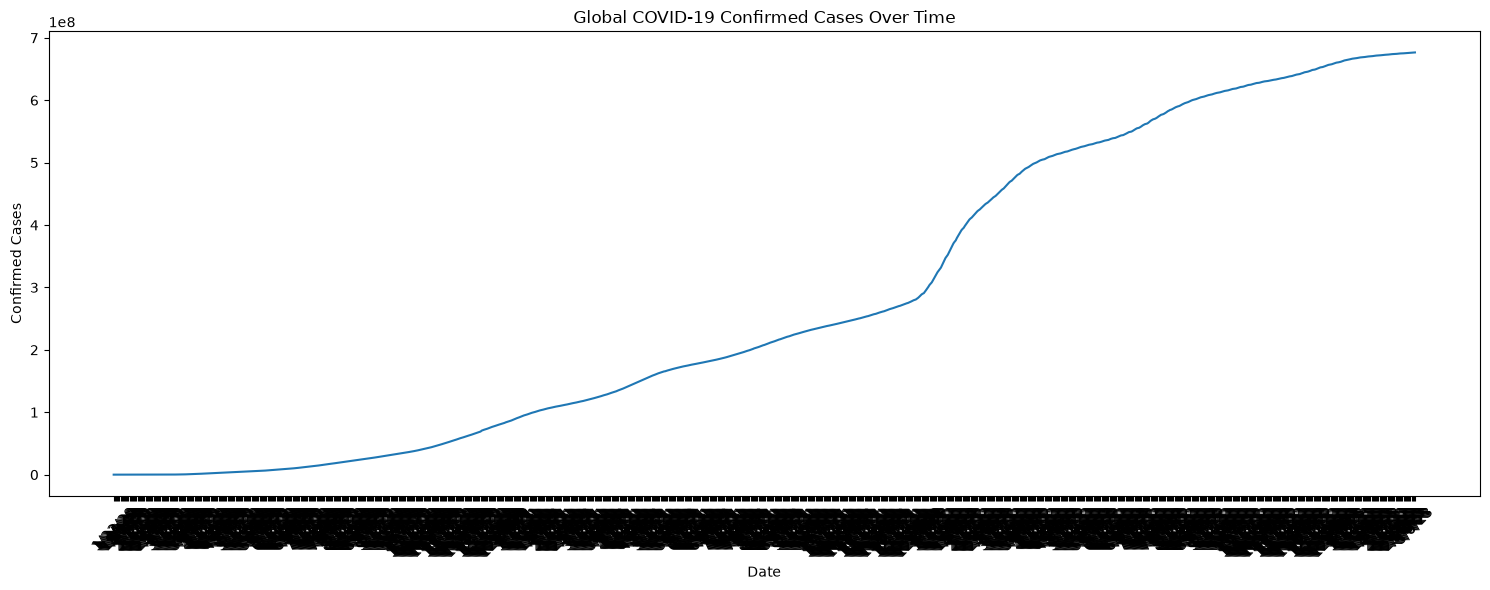

In [17]:
# Select only the date columns
date_data = df.iloc[:, 4:]

# Calculate total confirmed cases for each date
total_cases = date_data.sum()

# Create the line chart
plt.figure(figsize=(15,6))
plt.plot(total_cases.index, total_cases.values)
plt.title("Global COVID-19 Confirmed Cases Over Time")
plt.xlabel("Date")
plt.ylabel("Confirmed Cases")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [14]:
plt.figure(figsize=(15,6))
plt.plot(total_cases.index, total_cases.values)
plt.title("Global COVID-19 Confirmed Cases Over Time")
plt.xlabel("Date")
plt.ylabel("Confirmed Cases")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("../screenshots/confirmed_cases_line_chart.png")
plt.show()

NameError: name 'total_cases' is not defined

<Figure size 1500x600 with 0 Axes>

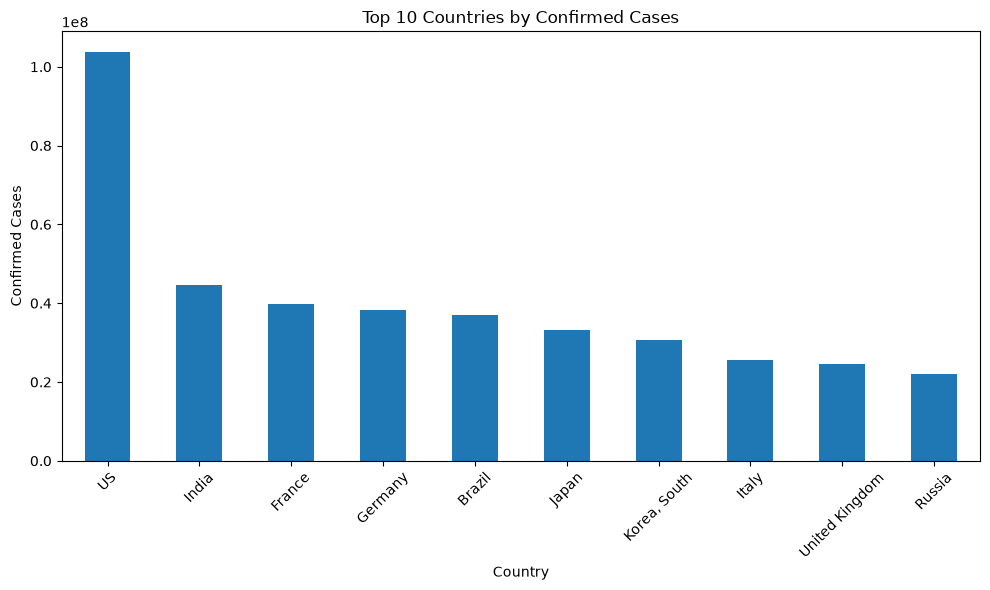

In [19]:
latest_cases = df.iloc[:, -1]

country_cases = df.groupby("Country/Region")[df.columns[-1]].sum()

top10 = country_cases.sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top10.plot(kind="bar")
plt.title("Top 10 Countries by Confirmed Cases")
plt.xlabel("Country")
plt.ylabel("Confirmed Cases")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

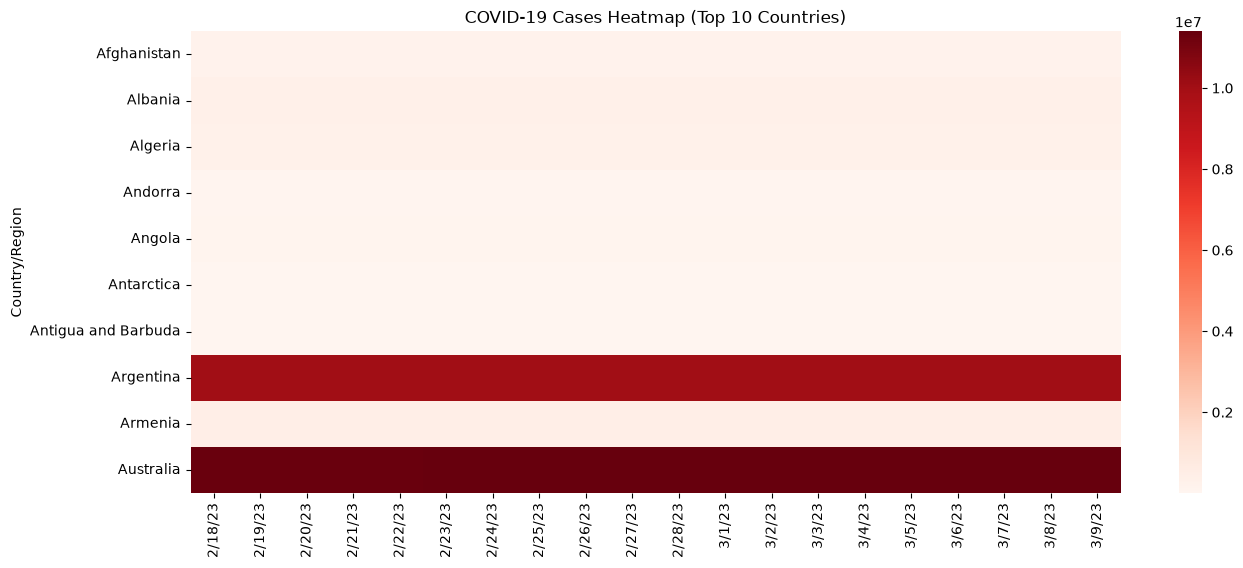

In [15]:
# Select the top 10 countries
top10_df = df.groupby("Country/Region").sum(numeric_only=True).head(10)

# Plot the heatmap
plt.figure(figsize=(15,6))
sns.heatmap(top10_df.iloc[:, -20:], cmap="Reds")

plt.title("COVID-19 Cases Heatmap (Top 10 Countries)")
plt.show()

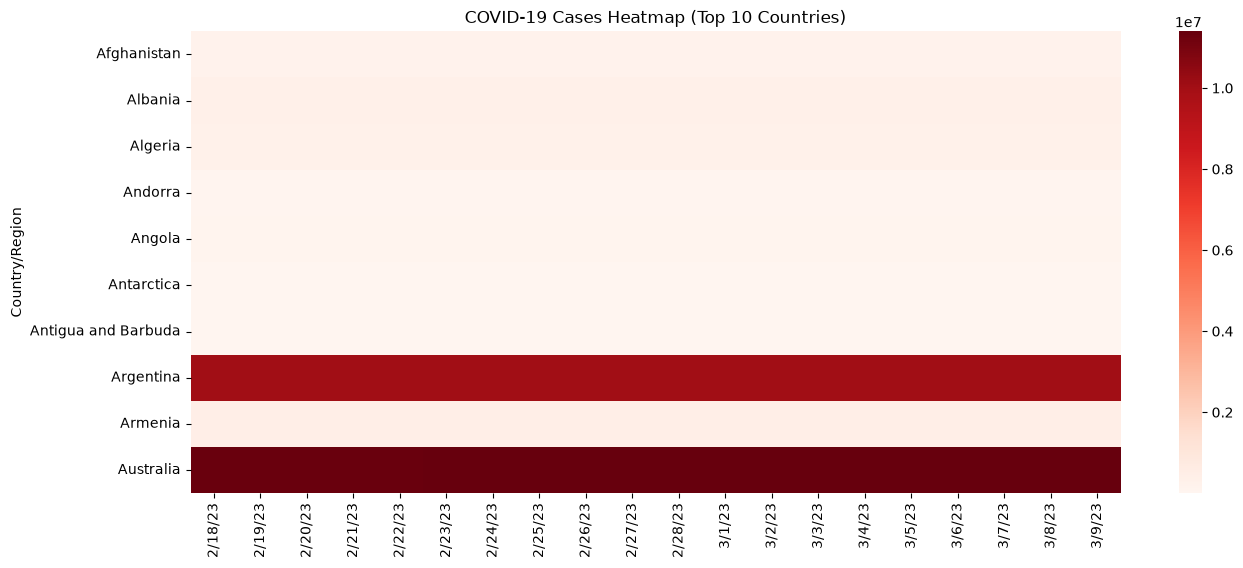

In [21]:
plt.figure(figsize=(15,6))
sns.heatmap(top10_df.iloc[:, -20:], cmap="Reds")

plt.title("COVID-19 Cases Heatmap (Top 10 Countries)")
plt.savefig("../screenshots/heatmap.png")
plt.show()

In [18]:
# Select only the date columns
date_data = df.iloc[:, 4:]

# Calculate total confirmed cases for each date
total_cases = date_data.sum()

prediction_df = pd.DataFrame({
    "Day": range(len(total_cases)),
    "Cases": total_cases.values
})

prediction_df.head()

,Day,Cases
0,0,557
1,1,657
2,2,944
3,3,1437
4,4,2120


In [19]:
from sklearn.model_selection import train_test_split

X = prediction_df[["Day"]]
y = prediction_df["Cases"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [21]:
# Predict on the test data
y_pred = model.predict(X_test)

results = pd.DataFrame({
    "Actual Cases": y_test.values,
    "Predicted Cases": y_pred.astype(int)
})

results.head(10)

,Actual Cases,Predicted Cases
0,10138935,-14936433
1,664042494,638220986
2,50533518,79180508
3,188331814,253969113
4,99103312,132961617
5,480078626,434418888
6,5945413,-36165818
7,215900,-87116342
8,138725902,190280957
9,122790345,171882157


In [22]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("R² Score:", r2)

Mean Absolute Error: 46900679.53969161
R² Score: 0.9495737534388945


In [23]:
future_days = pd.DataFrame({
    "Day": range(len(total_cases), len(total_cases) + 7)
})

future_predictions = model.predict(future_days)

prediction_result = pd.DataFrame({
    "Day": future_days["Day"],
    "Predicted Cases": future_predictions.astype(int)
})

prediction_result

,Day,Predicted Cases
0,1143,682095049
1,1144,682802695
2,1145,683510341
3,1146,684217987
4,1147,684925633
5,1148,685633280
6,1149,686340926


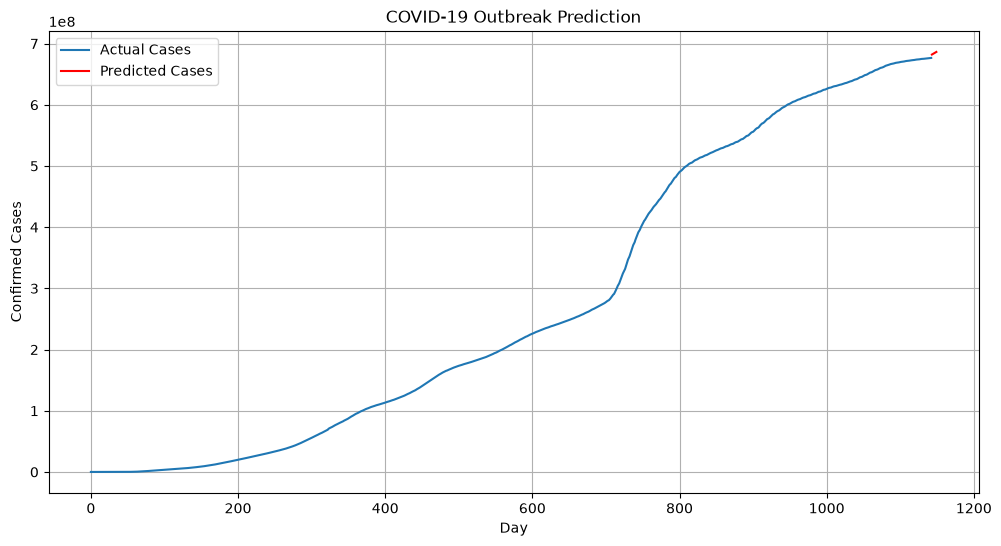

In [24]:
plt.figure(figsize=(12,6))

plt.plot(prediction_df["Day"], prediction_df["Cases"], label="Actual Cases")
plt.plot(future_days["Day"], future_predictions, color="red", label="Predicted Cases")

plt.title("COVID-19 Outbreak Prediction")
plt.xlabel("Day")
plt.ylabel("Confirmed Cases")
plt.legend()

plt.grid(True)
plt.show()

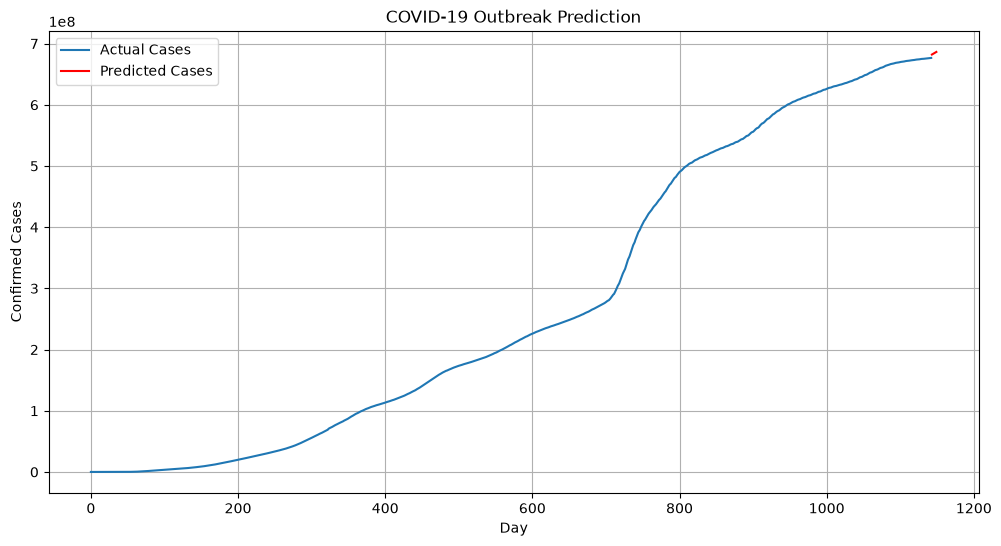

In [25]:
plt.figure(figsize=(12,6))

plt.plot(prediction_df["Day"], prediction_df["Cases"], label="Actual Cases")
plt.plot(future_days["Day"], future_predictions, color="red", label="Predicted Cases")

plt.title("COVID-19 Outbreak Prediction")
plt.xlabel("Day")
plt.ylabel("Confirmed Cases")
plt.legend()
plt.grid(True)

plt.savefig("../screenshots/prediction_graph.png")
plt.show()

In [26]:
import joblib

joblib.dump(model, "../models/outbreak_model.pkl")

print("✅ Model saved successfully!")

✅ Model saved successfully!
